<a href="https://colab.research.google.com/github/KsiuTretyakova/python_for_ML_ds_task/blob/main/HW9_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

У цьому домашньому завданні ми будемо працювати з набором даних Tips. Нижче інформація про нього.

**Про датасет:**

Tips - це датасет, який містить інформацію про рахунки та чайові в ресторані.

**Колонки датасету:**
- `total_bill` - загальна сума рахунку (долари)
- `tip` - розмір чайових (долари)
- `sex` - стать відвідувача (Male/Female)
- `smoker` - чи курить (Yes/No)
- `day` - день тижня (Thur/Fri/Sat/Sun)
- `time` - час відвідування (Lunch/Dinner)
- `size` - розмір групи (кількість людей)

**Джерело:** Оригінальні дані зібрані в одному з американських ресторанів у 1990-х роках. Скачати і переглянути набір даних можна тут: https://www.kaggle.com/datasets/sakshisatre/tips-dataset

А також ми вже вивантажили файл з даними і завантажили вам у Матеріали до цього модуля.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df = pd.read_csv('tips.csv')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4





**1. Гістограма розподілу рахунків**
Завантажте датасет Tips (Чайові) з файла у матеріалах `tips.csv`.
Створіть гістограму для колонки `total_bill` з 20 bins.
Опціонально можна додати підписи осей ОХ, ОУ, а також назву графіку.

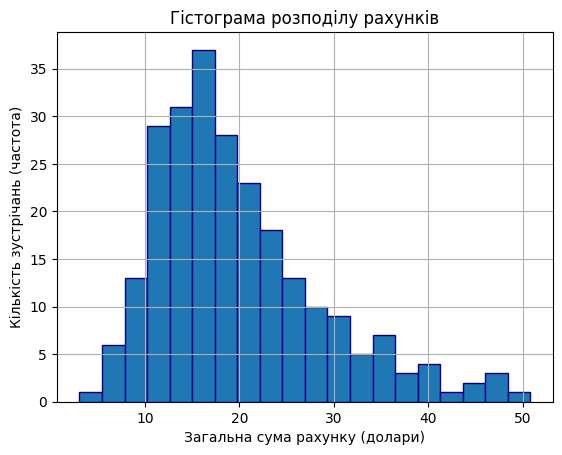

In [3]:
df.total_bill.hist(bins=20, edgecolor='darkblue')
plt.title('Гістограма розподілу рахунків')
plt.xlabel('Загальна сума рахунку (долари)')
plt.ylabel('Кількість зустрічань (частота)');

> Найчастіше сума рахунку складає від `10$` до `20$`. Якщо уточнювати, то у проміжку `15$ - 17.5$`

---

**2. Box plot чайових за днями тижня**

Створіть box plot, який показує розподіл чайових (`tip`) за днями тижня (`day`).
В який день навище медіанне (середнє) значення чайоивх? Зелена горизонтальна лінія всередині кожного box-plot.


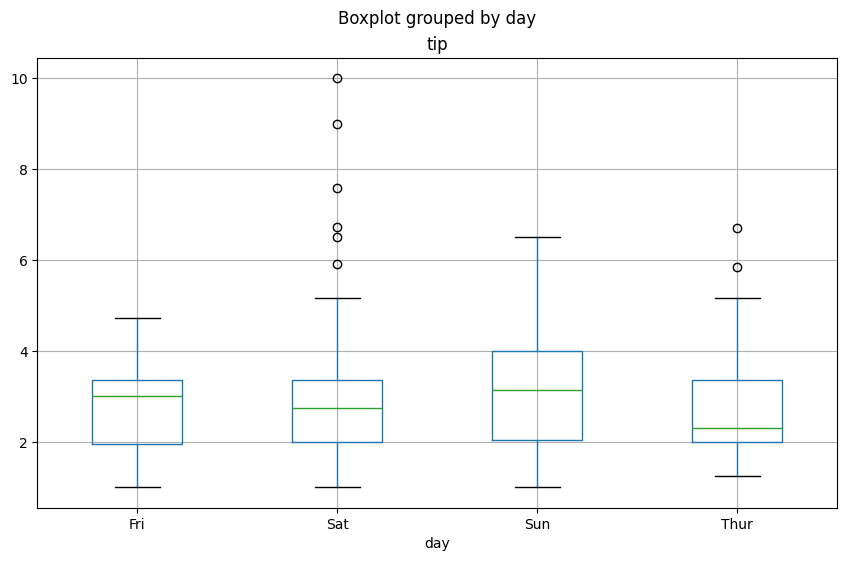

In [4]:
df.boxplot(column='tip', by='day', figsize=(10,6));
# plt.suptitle('')

> Найвище медіанне (середнє) значення чайоивх у неділю (Sun)  
1. Sun
2. Fri
3. Sat
4. Thur

---

**3. Scatter plot: рахунок vs чайові**

Створіть діаграму розсіювання для `total_bill` та `tip`.

<Figure size 1000x800 with 0 Axes>

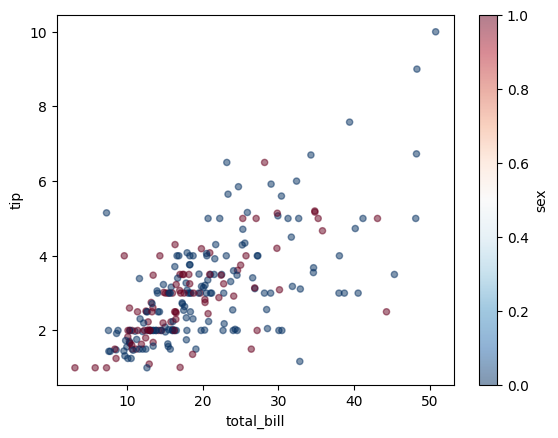

In [5]:
df_sex = df.copy()
df_sex['sex'] = (df_sex['sex']=='Female').astype(int)
plt.figure(figsize=(10,8))
df_sex.plot(kind='scatter', x='total_bill', y='tip',
            alpha=0.5, c='sex', colormap='RdBu_r',
            # s='size'
            )
plt.show()

In [6]:
df.sex.value_counts()

,count
sex,
Male,157
Female,87


> Залежність між чеком та кількістю чайових відслідковується, проте вона не значна. За графіком видно, що частіше чайові складають до 6 доларів. Найвищі чайові (від 6 до 10), частіше лишали чоловіки

---

**4. Bar chart: середній рахунок за часом**

Створіть стовпчасту діаграму середнього рахунку за часом дня (`time`).

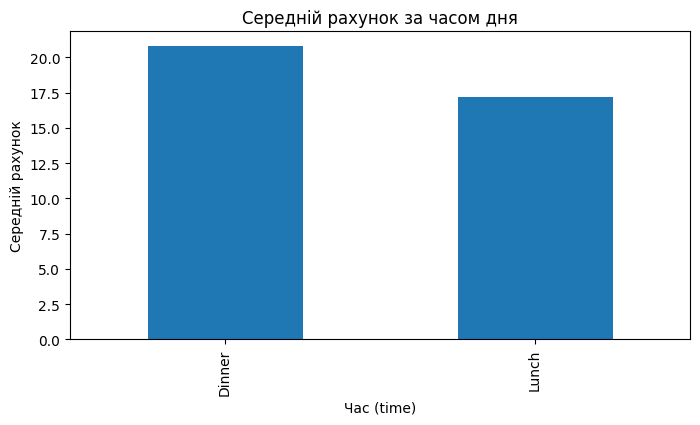

In [7]:
plt.figure(figsize=(8,4))
df.groupby('time')['total_bill'].mean().plot(kind='bar',)
plt.title('Середній рахунок за часом дня')
plt.xlabel('Час (time)')
plt.ylabel('Середній рахунок')
plt.show()

> Середній рахунок більший у вечорі (вечеря)

---

**5. Інтерактивна діаграма розсіювання**

Створіть з допомогою бібліотек Plotly інтерактивний scatter plot для `total_bill` vs `tip` з кольором за статтю (`sex`).


In [8]:
fig = px.scatter(df, x='total_bill', y='tip', color='sex', color_discrete_map={'Female': '#FF69B4', 'Male': '#1E90FF'},
                 hover_data=['time'],
                 size='size',
                 title='total_bill vs tip')
fig.show()

---

**6. Інтерактивний box plot: чайові за днями та статтю**

Створіть інтерактивний box plot для чайових за днями тижня з розбивкою за кольором по статі.

In [9]:
fig = px.box(df, x='day', y='tip', color='sex', color_discrete_map={'Female': '#FF69B4', 'Male': '#1E90FF'},
                 hover_data=['time', 'total_bill', 'size'],
                 title='day vs tip')
fig.show()

> У неділю та п'ятницю середні чайові від жінок більші, від чоловіків, котрі в свою чергу, дають більші чайові у суботу та четверг.  
Проте, загалом, чоловіки частіше лишають більші чайові.  
У нашій вибірці, жінок відвідує заклад значно менше, що впливає на середній чек чайових.